In [2]:
!pip install tensorflow opencv-python numpy matplotlib scikit-learn pillow

INFO: pip is looking at multiple versions of contourpy to determine which version is compatible with other requirements. This could take a while.
   ---------------------------------------- 0.0/350.9 MB ? eta -:--:--
   ---------------------------------------- 0.8/350.9 MB 4.2 MB/s eta 0:01:24
   ---------------------------------------- 1.6/350.9 MB 4.0 MB/s eta 0:01:28
   ---------------------------------------- 2.4/350.9 MB 4.2 MB/s eta 0:01:24
   ---------------------------------------- 3.1/350.9 MB 4.1 MB/s eta 0:01:25
   ---------------------------------------- 4.2/350.9 MB 4.3 MB/s eta 0:01:22
    --------------------------------------- 5.2/350.9 MB 4.3 MB/s eta 0:01:21
    --------------------------------------- 6.0/350.9 MB 4.3 MB/s eta 0:01:21
    --------------------------------------- 7.1/350.9 MB 4.3 MB/s eta 0:01:20
    --------------------------------------- 8.1/350.9 MB 4.4 MB/s eta 0:01:19
   - -------------------------------------- 8.9/350.9 MB 4.4 MB/s eta 0:01:18
   

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.2.6 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.2.6 which is incompatible.
pydantic-settings 2.6.1 requires pydantic>=2.7.0, but you have pydantic 1.10.22 which is incompatible.
streamlit 1.37.1 requires protobuf<6,>=3.20, but you have protobuf 7.34.0 which is incompatible.


In [1]:
import tensorflow as tf
import numpy as np

print(tf.__version__)
print(np.__version__)


2.15.0
1.24.3


In [3]:
import kagglehub
import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

In [4]:
# Download dataset
path = kagglehub.dataset_download("mohamedgobara/oral-lesions-malignancy-detection-dataset")

print("Dataset downloaded to:", path)

dataset_path = os.path.join(path, "Oral Images Dataset", "original_data")

print("Dataset folder:", dataset_path)
print("Folders inside dataset:", os.listdir(dataset_path))

Dataset downloaded to: C:\Users\DELL\.cache\kagglehub\datasets\mohamedgobara\oral-lesions-malignancy-detection-dataset\versions\1
Dataset folder: C:\Users\DELL\.cache\kagglehub\datasets\mohamedgobara\oral-lesions-malignancy-detection-dataset\versions\1\Oral Images Dataset\original_data
Folders inside dataset: ['benign_lesions', 'malignant_lesions']


In [5]:
import random

In [6]:
IMG_SIZE = 128

images = []
labels = []

In [7]:
classes = os.listdir(dataset_path)

print("Classes:", classes)

for label, folder in enumerate(classes):

    folder_path = os.path.join(dataset_path, folder)

    for img_name in os.listdir(folder_path):

        img_path = os.path.join(folder_path, img_name)

        img = cv2.imread(img_path)

        if img is None:
            continue

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        images.append(img)
        labels.append(label)

images = np.array(images) / 255.0
labels = np.array(labels)

print("Total Images Loaded:", len(images))
print("Label Values:", np.unique(labels))

Classes: ['benign_lesions', 'malignant_lesions']
Total Images Loaded: 323
Label Values: [0 1]


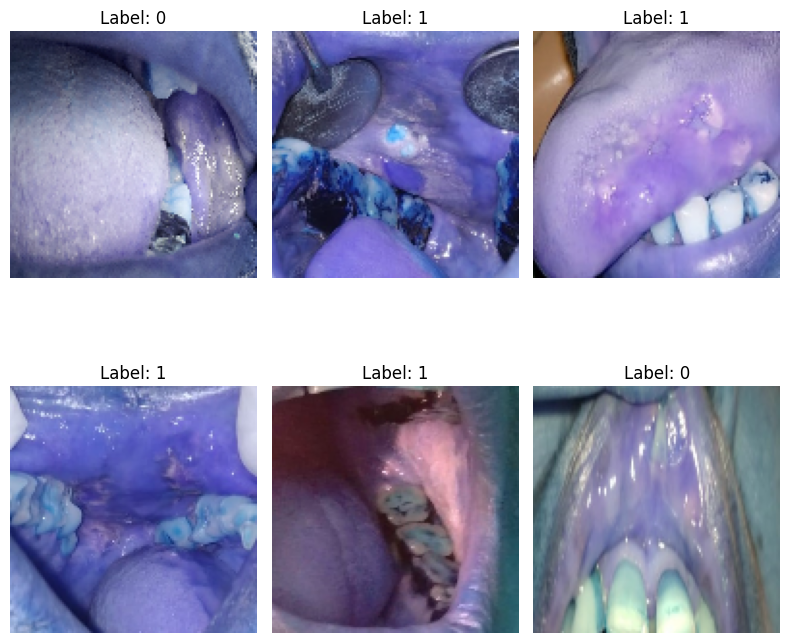

In [8]:
plt.figure(figsize=(8,8))

for i in range(6):

    idx = random.randint(0, len(images)-1)

    plt.subplot(2,3,i+1)
    plt.imshow(images[idx])
    plt.title("Label: " + str(labels[idx]))
    plt.axis("off")

plt.tight_layout()
plt.show()

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    images,
    labels,
    test_size=0.2,
    random_state=42
)

print("Training Images:", len(X_train))
print("Testing Images:", len(X_test))

Training Images: 258
Testing Images: 65


In [16]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(128,128,3)
)

x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(128, activation='relu')(x)

predictions = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=predictions)

9406464/9406464 [==============================] - 3s 0us/step


In [17]:
for layer in base_model.layers:
    layer.trainable = False

In [19]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [20]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 128, 128, 3)]        0         []                            
                                                                                                  
 Conv1 (Conv2D)              (None, 64, 64, 32)           864       ['input_1[0][0]']             
                                                                                                  
 bn_Conv1 (BatchNormalizati  (None, 64, 64, 32)           128       ['Conv1[0][0]']               
 on)                                                                                              
                                                                                                  
 Conv1_relu (ReLU)           (None, 64, 64, 32)           0         ['bn_Conv1[0][0]']        

In [21]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

datagen.fit(X_train)

In [22]:
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=16),
    epochs=10,
    validation_data=(X_test, y_test),
    steps_per_epoch=len(X_train) // 16
)

Epoch 1/10
16/16 [==============================] - 19s 575ms/step - loss: 0.8451 - accuracy: 0.5289 - val_loss: 0.4943 - val_accuracy: 0.8154
Epoch 2/10
16/16 [==============================] - 6s 390ms/step - loss: 0.5270 - accuracy: 0.7521 - val_loss: 0.4851 - val_accuracy: 0.8462
Epoch 3/10
16/16 [==============================] - 6s 393ms/step - loss: 0.4413 - accuracy: 0.8223 - val_loss: 0.4123 - val_accuracy: 0.8000
Epoch 4/10
16/16 [==============================] - 7s 408ms/step - loss: 0.3736 - accuracy: 0.8430 - val_loss: 0.4240 - val_accuracy: 0.8154
Epoch 5/10
16/16 [==============================] - 6s 394ms/step - loss: 0.3203 - accuracy: 0.8719 - val_loss: 0.4811 - val_accuracy: 0.8769
Epoch 6/10
16/16 [==============================] - 6s 395ms/step - loss: 0.2916 - accuracy: 0.8843 - val_loss: 0.4397 - val_accuracy: 0.8308
Epoch 7/10
16/16 [==============================] - 7s 393ms/step - loss: 0.2865 - accuracy: 0.8843 - val_loss: 0.4135 - val_accuracy: 0.8615
Epoch

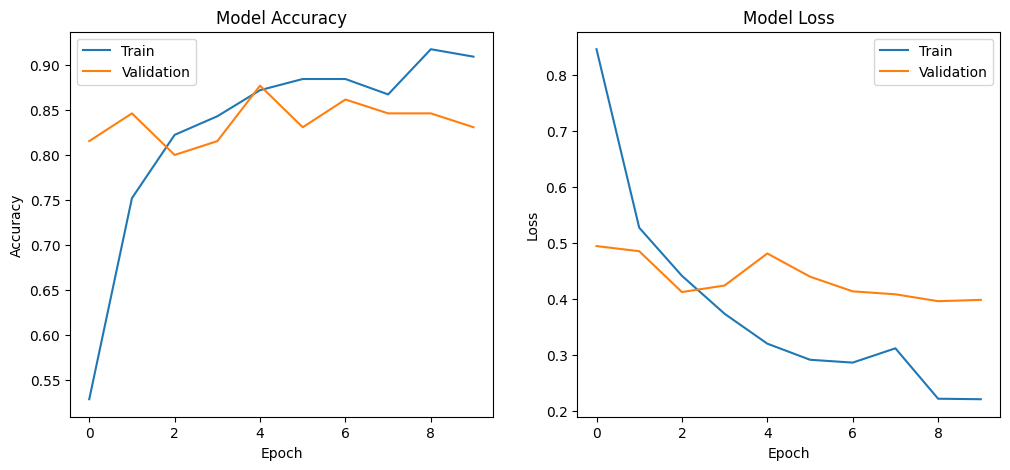

In [23]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])

plt.show()

In [24]:
import os

os.makedirs("models", exist_ok=True)

model.save("models/oral_cancer_model.h5")

print("Model saved successfully!")

c:\Users\DELL\anaconda3\envs\oral_ai\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Model saved successfully!


1/1 [==============================] - 3s 3s/step
Prediction Score: 0.03553463


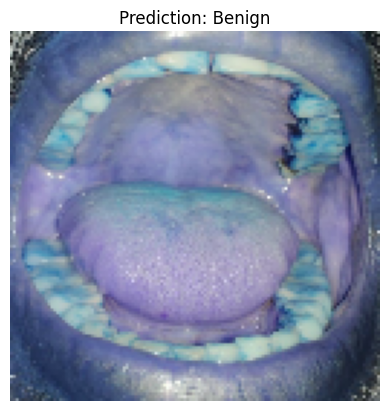

In [25]:
import random

# pick a random image from test set
idx = random.randint(0, len(X_test)-1)

test_img = X_test[idx]

prediction = model.predict(np.expand_dims(test_img, axis=0))[0][0]

if prediction > 0.5:
    result = "Malignant"
else:
    result = "Benign"

plt.imshow(test_img)
plt.title("Prediction: " + result)
plt.axis("off")

print("Prediction Score:", prediction)